In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("../dataset/supermarket_sales.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [5]:
df.shape

(1000, 17)

In [6]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   str    
 1   Branch                   1000 non-null   str    
 2   City                     1000 non-null   str    
 3   Customer type            1000 non-null   str    
 4   Gender                   1000 non-null   str    
 5   Product line             1000 non-null   str    
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   str    
 11  Time                     1000 non-null   str    
 12  Payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  1000 non-nu

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

print("Date converted successfully!")

Date converted successfully!


In [12]:
df['Date'].dtype

dtype('<M8[us]')

In [13]:
df['Time'] = pd.to_datetime(df['Time'], format='%H:%M').dt.time

print("Time converted successfully!")

Time converted successfully!


In [14]:
df[['Date', 'Time']].head()

,Date,Time
0,2019-01-05,13:08:00
1,2019-03-08,10:29:00
2,2019-03-03,13:23:00
3,2019-01-27,20:33:00
4,2019-02-08,10:37:00


In [15]:
df['Month'] = df['Date'].dt.month

print("Month column created!")

Month column created!


In [16]:
df['Day'] = df['Date'].dt.day

print("Day column created!")

Day column created!


In [17]:
df['Hour'] = df['Time'].apply(lambda x: x.hour)

print("Hour column created!")

Hour column created!


In [18]:
df[['Date', 'Time', 'Month', 'Day', 'Hour']].head()

,Date,Time,Month,Day,Hour
0,2019-01-05,13:08:00,1,5,13
1,2019-03-08,10:29:00,3,8,10
2,2019-03-03,13:23:00,3,3,13
3,2019-01-27,20:33:00,1,27,20
4,2019-02-08,10:37:00,2,8,10


In [19]:
sales_by_product = df.groupby('Product line')['Total'].sum().sort_values(ascending=False)

sales_by_product

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Total, dtype: float64

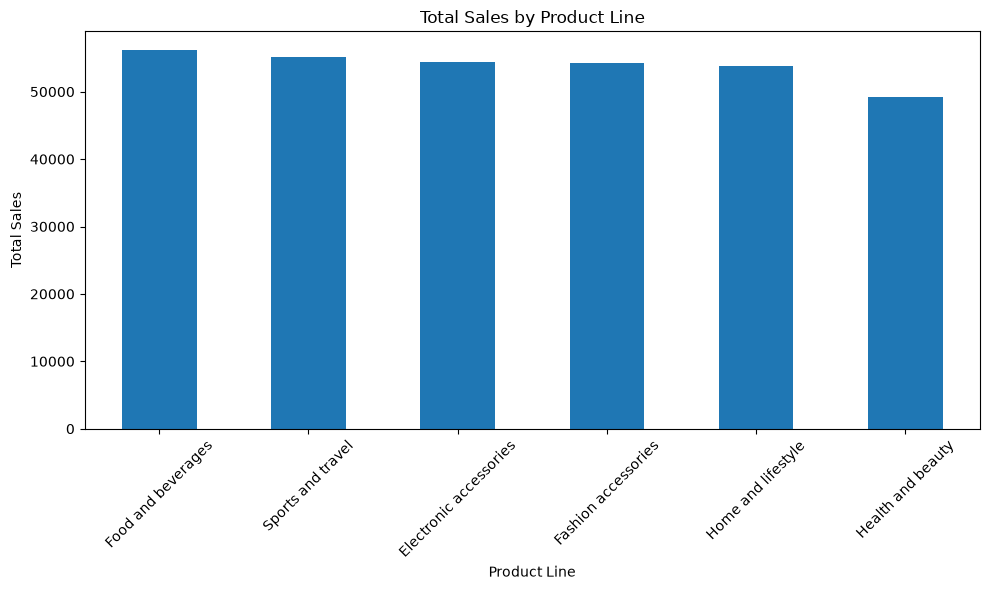

In [21]:
plt.figure(figsize=(10, 6))

sales_by_product.plot(kind='bar')

plt.title('Total Sales by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visualizations/sales_by_product_line.png", dpi=300, bbox_inches='tight')

plt.show()

In [22]:
sales_by_branch = df.groupby('Branch')['Total'].sum().sort_values(ascending=False)

sales_by_branch

Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Total, dtype: float64

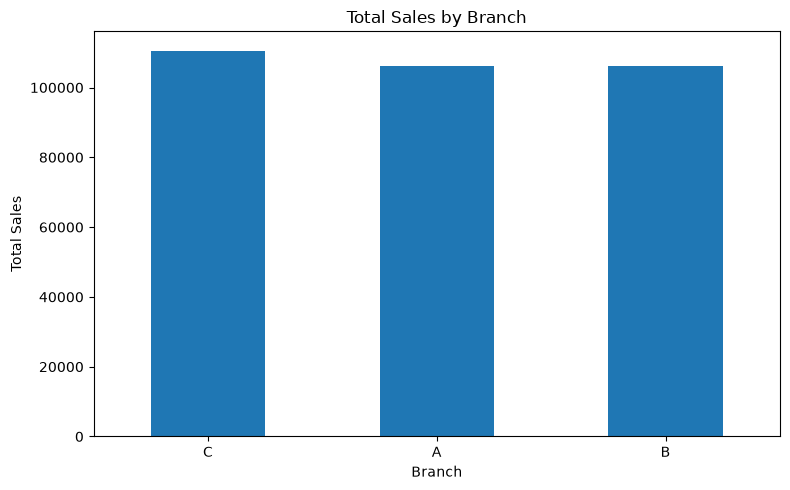

In [23]:
plt.figure(figsize=(8, 5))

sales_by_branch.plot(kind='bar')

plt.title('Total Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/sales_by_branch.png", dpi=300, bbox_inches='tight')

plt.show()

In [24]:
sales_by_city = df.groupby('City')['Total'].sum().sort_values(ascending=False)

sales_by_city

City
Naypyitaw    110568.7065
Yangon       106200.3705
Mandalay     106197.6720
Name: Total, dtype: float64

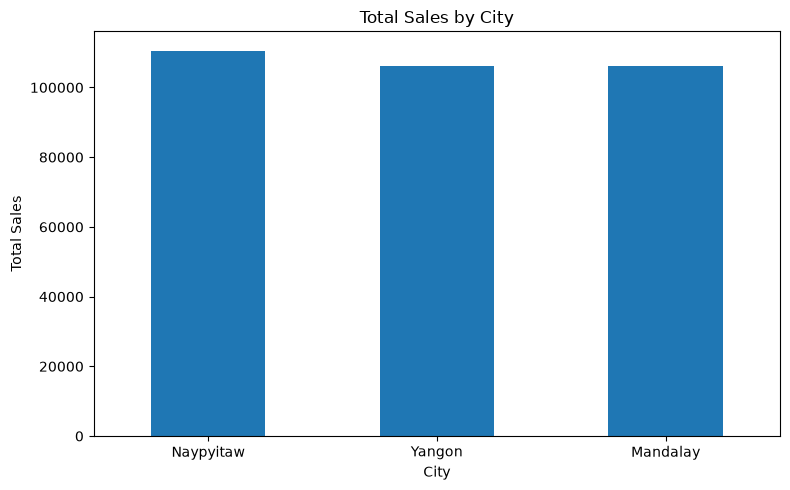

In [25]:
plt.figure(figsize=(8, 5))

sales_by_city.plot(kind='bar')

plt.title('Total Sales by City')
plt.xlabel('City')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/sales_by_city.png", dpi=300, bbox_inches='tight')

plt.show()

In [26]:
sales_by_customer = df.groupby('Customer type')['Total'].sum().sort_values(ascending=False)

sales_by_customer

Customer type
Member    164223.444
Normal    158743.305
Name: Total, dtype: float64

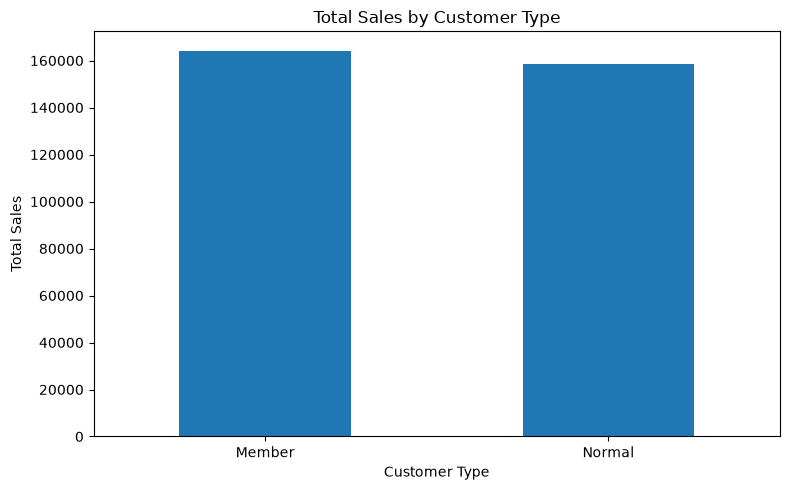

In [27]:
plt.figure(figsize=(8, 5))

sales_by_customer.plot(kind='bar')

plt.title('Total Sales by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/sales_by_customer_type.png", dpi=300, bbox_inches='tight')

plt.show()

In [28]:
sales_by_gender = df.groupby('Gender')['Total'].sum().sort_values(ascending=False)

sales_by_gender

Gender
Female    167882.925
Male      155083.824
Name: Total, dtype: float64

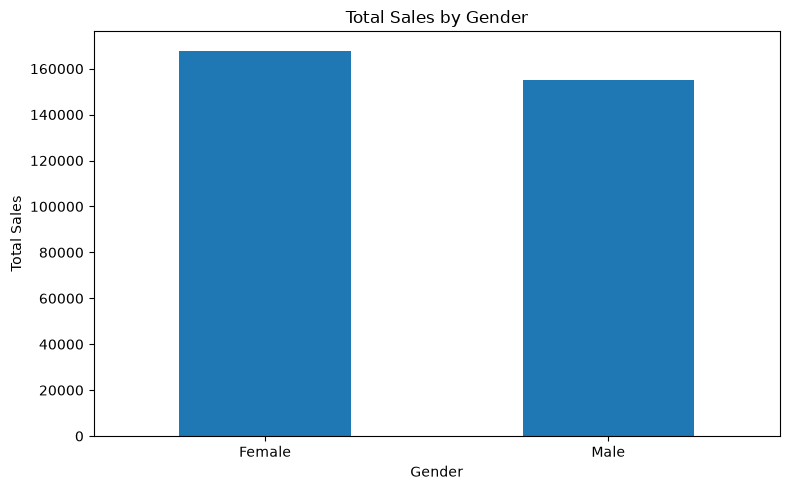

In [29]:
plt.figure(figsize=(8, 5))

sales_by_gender.plot(kind='bar')

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/sales_by_gender.png", dpi=300, bbox_inches='tight')

plt.show()

In [30]:
payment_counts = df['Payment'].value_counts()

payment_counts

Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

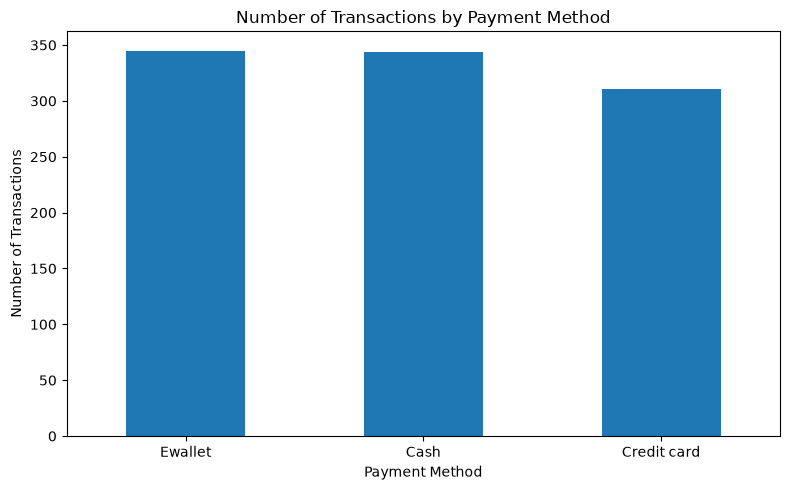

In [31]:
plt.figure(figsize=(8, 5))

payment_counts.plot(kind='bar')

plt.title('Number of Transactions by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/payment_method_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

In [32]:
sales_by_payment = df.groupby('Payment')['Total'].sum().sort_values(ascending=False)

sales_by_payment

Payment
Cash           112206.570
Ewallet        109993.107
Credit card    100767.072
Name: Total, dtype: float64

In [33]:
daily_sales = df.groupby('Date')['Total'].sum()

daily_sales.head()

Date
2019-01-01    4745.1810
2019-01-02    1945.5030
2019-01-03    2078.1285
2019-01-04    1623.6885
2019-01-05    3536.6835
Name: Total, dtype: float64

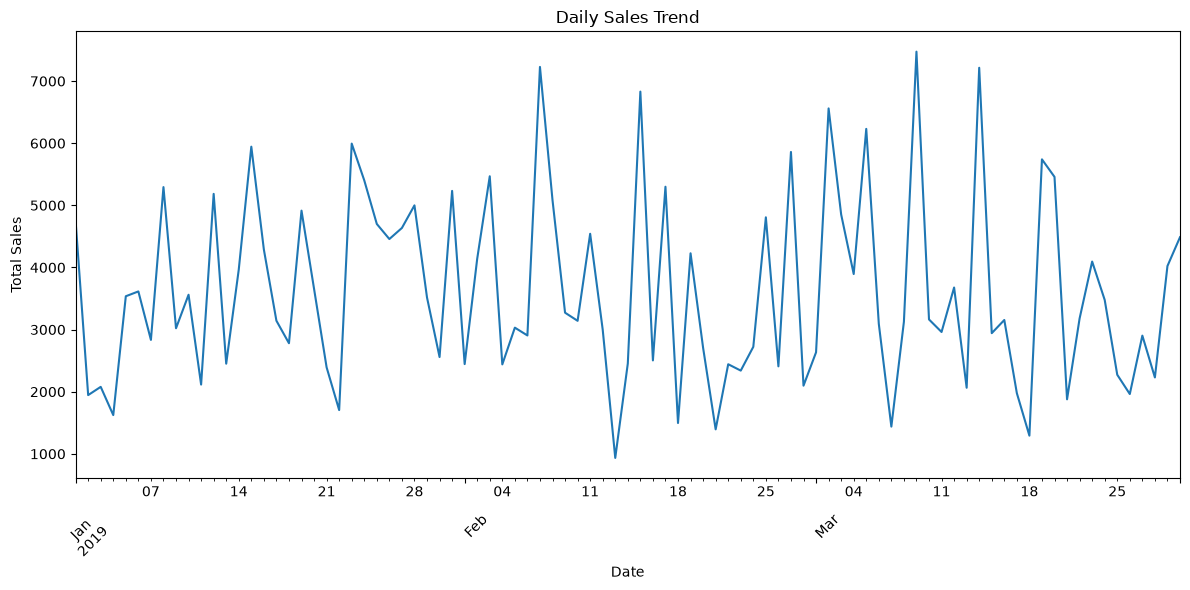

In [34]:
plt.figure(figsize=(12, 6))

daily_sales.plot(kind='line')

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visualizations/daily_sales_trend.png", dpi=300, bbox_inches='tight')

plt.show()

In [35]:
monthly_sales = df.groupby('Month')['Total'].sum()

monthly_sales

Month
1    116291.868
2     97219.374
3    109455.507
Name: Total, dtype: float64

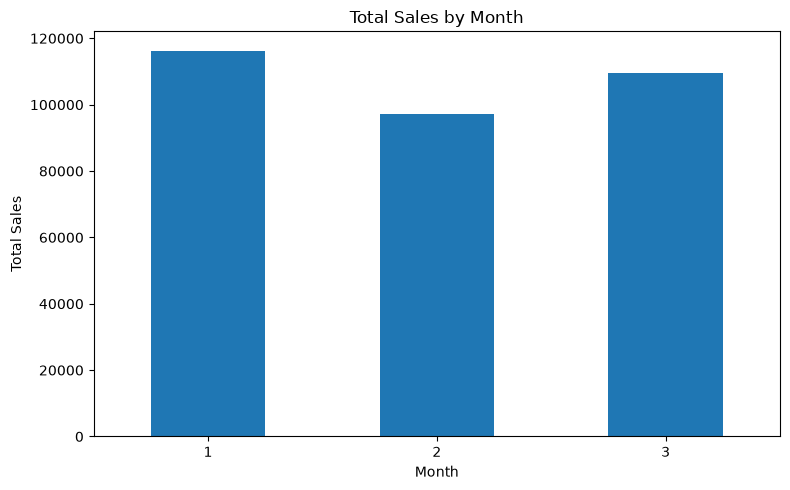

In [36]:
plt.figure(figsize=(8, 5))

monthly_sales.plot(kind='bar')

plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../visualizations/monthly_sales.png", dpi=300, bbox_inches='tight')

plt.show()

In [37]:
rating_by_product = df.groupby('Product line')['Rating'].mean().sort_values(ascending=False)

rating_by_product

Product line
Food and beverages        7.113218
Fashion accessories       7.029213
Health and beauty         7.003289
Electronic accessories    6.924706
Sports and travel         6.916265
Home and lifestyle        6.837500
Name: Rating, dtype: float64

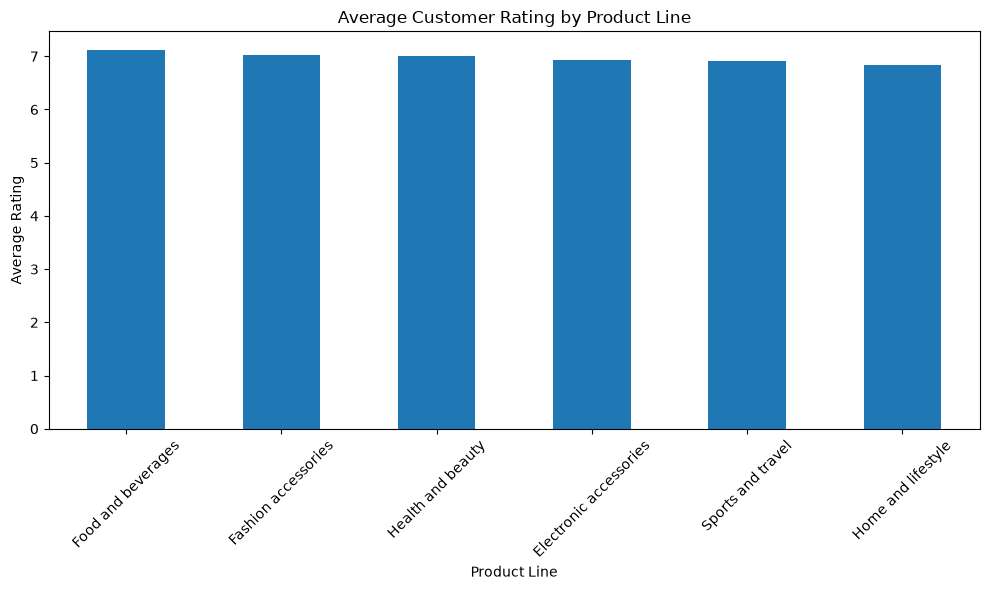

In [38]:
plt.figure(figsize=(10, 6))

rating_by_product.plot(kind='bar')

plt.title('Average Customer Rating by Product Line')
plt.xlabel('Product Line')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../visualizations/average_rating_by_product.png", dpi=300, bbox_inches='tight')

plt.show()

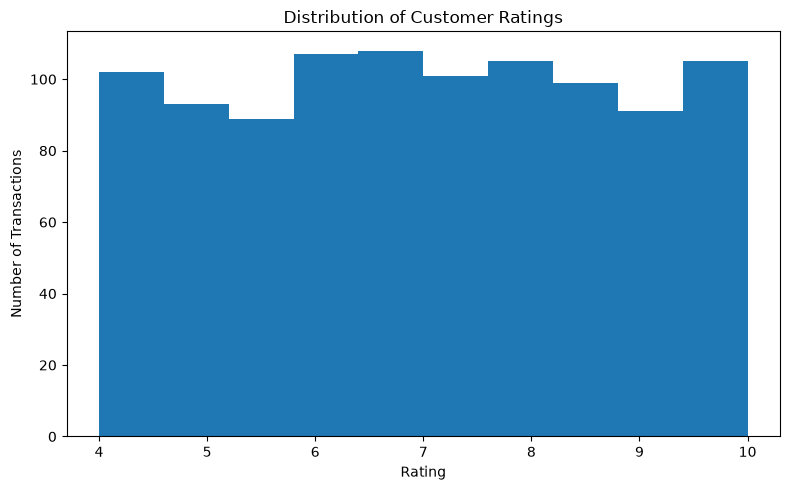

In [39]:
plt.figure(figsize=(8, 5))

plt.hist(df['Rating'], bins=10)

plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Transactions')
plt.tight_layout()

plt.savefig("../visualizations/rating_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

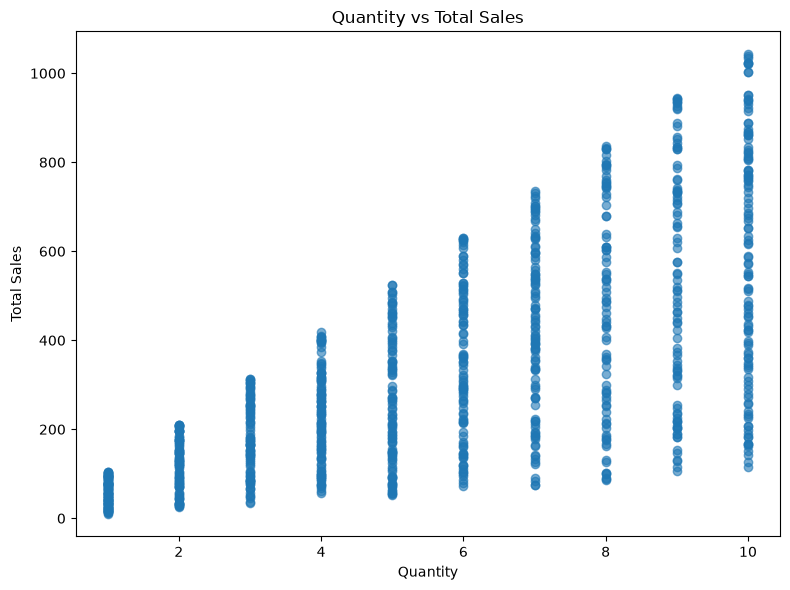

In [40]:
plt.figure(figsize=(8, 6))

plt.scatter(df['Quantity'], df['Total'], alpha=0.6)

plt.title('Quantity vs Total Sales')
plt.xlabel('Quantity')
plt.ylabel('Total Sales')
plt.tight_layout()

plt.savefig("../visualizations/quantity_vs_total_sales.png", dpi=300, bbox_inches='tight')

plt.show()

In [41]:
df['Quantity'].corr(df['Total'])

np.float64(0.7055101859433063)

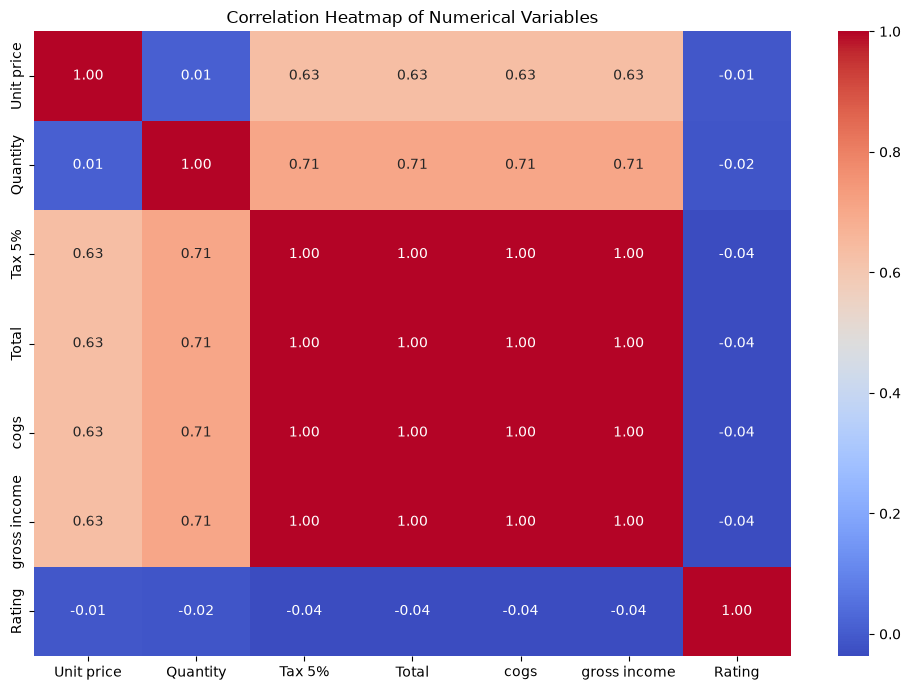

In [42]:
numeric_cols = ['Unit price', 'Quantity', 'Tax 5%', 'Total',
                'cogs', 'gross income', 'Rating']

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()

plt.savefig("../visualizations/correlation_heatmap.png",
            dpi=300, bbox_inches='tight')

plt.show()

In [43]:
sales_by_hour = df.groupby('Hour')['Total'].sum().sort_index()

print(sales_by_hour)

Hour
10    31421.4810
11    30377.3295
12    26065.8825
13    34723.2270
14    30828.3990
15    31179.5085
16    25226.3235
17    24445.2180
18    26030.3400
19    39699.5130
20    22969.5270
Name: Total, dtype: float64


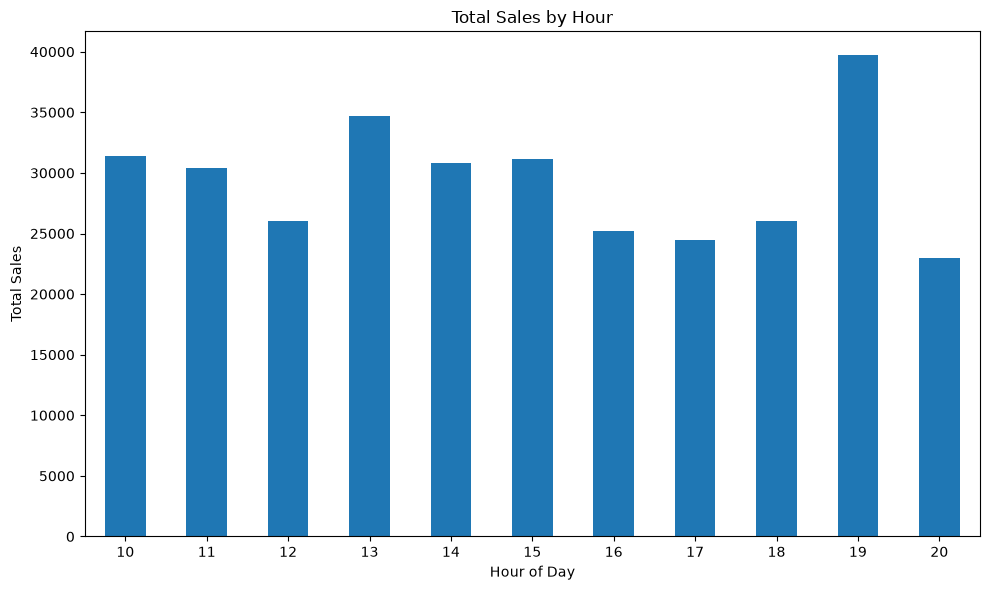

In [44]:
plt.figure(figsize=(10, 6))

sales_by_hour.plot(kind='bar')

plt.title('Total Sales by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("../visualizations/sales_by_hour.png",
            dpi=300, bbox_inches='tight')

plt.show()

In [45]:
print("========== SUPERMARKET SALES EDA SUMMARY ==========\n")

print("Total Sales:", round(df['Total'].sum(), 2))
print("Average Transaction Value:", round(df['Total'].mean(), 2))
print("Average Customer Rating:", round(df['Rating'].mean(), 2))

print("\nTop Product Line:", sales_by_product.idxmax())
print("Top Branch:", sales_by_branch.idxmax())
print("Top City:", sales_by_city.idxmax())
print("Top Customer Type:", sales_by_customer.idxmax())
print("Most Used Payment Method:", payment_counts.idxmax())

print("\nHighest Sales Hour:", sales_by_hour.idxmax())
print("Quantity vs Total Sales Correlation:",
      round(df['Quantity'].corr(df['Total']), 2))

========== SUPERMARKET SALES EDA SUMMARY ==========

Total Sales: 322966.75
Average Transaction Value: 322.97
Average Customer Rating: 6.97

Top Product Line: Food and beverages
Top Branch: C
Top City: Naypyitaw
Top Customer Type: Member
Most Used Payment Method: Ewallet

Highest Sales Hour: 19
Quantity vs Total Sales Correlation: 0.71


# Key Findings

## 1. Sales Performance
- The dataset contains 1000 supermarket transactions.
- The total sales were 322,966.75.
- The average transaction value was 322.97.

## 2. Product Line Analysis
- Food and beverages generated the highest total sales among the product lines.

## 3. Branch and City Analysis
- Branch C recorded the highest total sales among the branches.
- Naypyitaw recorded the highest total sales among the cities.

## 4. Customer Analysis
- Members generated the highest total sales among the customer types.
- Sales were also analyzed based on gender.

## 5. Payment Analysis
- Ewallet was the most frequently used payment method.

## 6. Time-Based Analysis
- Daily, monthly, and hourly sales were analyzed.
- The highest sales occurred around hour 19 (7 PM).

## 7. Customer Ratings
- The average customer rating was 6.97.
- Ratings were analyzed across different product lines.

## 8. Quantity and Sales Relationship
- The correlation between Quantity and Total Sales was approximately 0.71.
- This indicates a positive relationship between quantity purchased and total transaction value.

## 9. Data Quality
- No missing values were found.
- No duplicate records were found.
- Date and Time columns were converted into appropriate formats for analysis.

# Conclusion

The Exploratory Data Analysis of the Supermarket Sales dataset provided useful insights into sales performance, customer behavior, product lines, payment methods, and sales patterns over time.

The analysis showed that Food and beverages had the highest total sales, Branch C and Naypyitaw recorded the highest sales among their respective groups, and Ewallet was the most frequently used payment method.

The positive correlation of approximately 0.71 between Quantity and Total Sales indicates that transactions involving larger quantities generally had higher total transaction values.

Overall, the project demonstrated how Python, Pandas, Matplotlib, and Seaborn can be used to clean, analyze, visualize, and interpret real-world sales data.